# 01 — Data Loading & Corpus Exploration
**HC3: Human vs. ChatGPT Text Analysis**

Loads the HC3 dataset from HuggingFace, flattens into documents, computes basic statistics, and saves the sampled document list used by all downstream notebooks.

**Output:** `data/docs_sampled.csv`

In [1]:
import pandas as pd
import numpy as np
import requests
import json
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('../data', exist_ok=True)
os.makedirs('../images', exist_ok=True)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 100)
print('Libraries loaded.')

Libraries loaded.


## 1. Load HC3 from HuggingFace

In [2]:
urls = {
    'reddit_eli5': 'https://huggingface.co/datasets/Hello-SimpleAI/HC3/resolve/main/reddit_eli5.jsonl',
    'open_qa': 'https://huggingface.co/datasets/Hello-SimpleAI/HC3/resolve/main/open_qa.jsonl',
    'medicine': 'https://huggingface.co/datasets/Hello-SimpleAI/HC3/resolve/main/medicine.jsonl',
    'finance': 'https://huggingface.co/datasets/Hello-SimpleAI/HC3/resolve/main/finance.jsonl',
    'wiki_csai': 'https://huggingface.co/datasets/Hello-SimpleAI/HC3/resolve/main/wiki_csai.jsonl',
}

records = []
for source, url in urls.items():
    response= requests.get(url)
    for line in response.text.strip().split('\n'):
        row =json.loads(line)
        row['source']= source
        records.append(row)

df_raw = pd.DataFrame(records)
print(f'Raw rows: {len(df_raw):,}')
df_raw.head(3)

Raw rows: 24,322


,question,human_answers,chatgpt_answers,index,source
0,"Why is every book I hear about a "" NY Times # 1 Best Seller "" ? ELI5 : Why is every book I hear ...","[Basically there are many categories of "" Best Seller "" . Replace "" Best Seller "" by something l...","[There are many different best seller lists that are published by various organizations, and the...",NaN,reddit_eli5
1,"If salt is so bad for cars , why do we use it on the roads ? As the title states , why do we use...",[salt is good for not dying in car crashes and car crashes are worse for cars then salt . Some p...,[Salt is used on roads to help melt ice and snow and improve traction during the winter months. ...,NaN,reddit_eli5
2,Why do we still have SD TV channels when HD looks like SD on an old TV ? Could n't we just have ...,[The way it works is that old TV stations got a certain amount of bandwidth to replace their old...,[There are a few reasons why we still have SD (standard definition) TV channels: \n1. Some peopl...,NaN,reddit_eli5


## 2. Flatten into one document per response

In [3]:
records = []
for idx, row in df_raw.iterrows():
    for i, ans in enumerate(row['human_answers']):
        records.append({'doc_id': f'{idx}_H{i}', 'question_id': idx,
                        'question': row['question'], 'text': ans,
                        'author_type': 'human', 'source': row['source']})
    for i, ans in enumerate(row['chatgpt_answers']):
        records.append({'doc_id': f'{idx}_AI{i}', 'question_id': idx,
                        'question': row['question'], 'text': ans,
                        'author_type': 'chatgpt', 'source': row['source']})

docs = pd.DataFrame(records)
docs['char_length'] = docs['text'].str.len()
docs['word_count']= docs['text'].str.split().str.len()
docs = docs[docs['char_length'] >0].reset_index(drop=True)
print(f'Total documents: {len(docs):,}')

Total documents: 85,431


## 3. Corpus statistics (Q1–Q3)

In [4]:
print('Q1. How many documents?')
print(f'Total: {len(docs):,}')
print(docs['author_type'].value_counts().to_string())
print(docs['source'].value_counts().to_string())

print('\nQ2. Average length')
print(docs['char_length'].describe().round(1).to_string())
print(docs.groupby('author_type')['char_length'].mean().round(1).to_string())

print('\nQ3. Min / Max')
shortest = docs.loc[docs['char_length'].idxmin()]
longest  = docs.loc[docs['char_length'].idxmax()]
print(f"Shortest: {shortest['doc_id']} | {shortest['author_type']} | {shortest['char_length']} chars")
print(f"Longest:  {longest['doc_id']}  | {longest['author_type']}  | {longest['char_length']} chars")

Q1. How many documents?
Total: 85,431
author_type
human      58546
chatgpt    26885
source
reddit_eli5    67996
finance         8436
open_qa         4733
medicine        2582
wiki_csai       1684

Q2. Average length
count    85431.0
mean       784.7
std        732.6
min          5.0
25%        289.0
50%        631.0
75%       1085.0
max      36793.0
author_type
chatgpt    1011.2
human       680.7

Q3. Min / Max
Shortest: 18402_H0 | human | 5 chars
Longest:  15050_H0  | human  | 36793 chars


## 4. OHCO structure

In [5]:
ohco = docs.copy()
ohco['para_num'] = ohco['text'].apply(lambda x: len([p for p in x.split('\n') if p.strip()]))

print('OHCO levels derived from data:')
print(f" source — {ohco['source'].nunique()} unique values: {ohco['source'].unique().tolist()}")
print(f" question_id — {ohco['question_id'].nunique():,} unique questions")
print(f" doc_id — {ohco['doc_id'].nunique():,} unique documents")
print(f" para_num — avg {ohco['para_num'].mean():.1f} paragraphs per document")
print(f" sent_num — computed at parse time via NLTK sent_tokenize")
print(f" token_num — avg {ohco['word_count'].mean():.1f} tokens per document")
ohco[['source','question_id','doc_id','para_num','word_count']].head(8)

OHCO levels derived from data:
 source — 5 unique values: ['reddit_eli5', 'open_qa', 'medicine', 'finance', 'wiki_csai']
 question_id — 24,322 unique questions
 doc_id — 85,431 unique documents
 para_num — avg 1.3 paragraphs per document
 sent_num — computed at parse time via NLTK sent_tokenize
 token_num — avg 146.2 tokens per document


,source,question_id,doc_id,para_num,word_count
0,reddit_eli5,0,0_H0,1,134
1,reddit_eli5,0,0_H1,1,73
2,reddit_eli5,0,0_H2,1,62
3,reddit_eli5,0,0_AI0,3,207
4,reddit_eli5,1,1_H0,1,41
5,reddit_eli5,1,1_H1,1,116
6,reddit_eli5,1,1_H2,1,260
7,reddit_eli5,1,1_AI0,3,199


## 5. Sample to token budget (500K–2M)

In [6]:
TARGET_WORDS = 1_500_000
total_words= docs['word_count'].sum()
print(f'Total words before sampling: {total_words:,}')

if total_words > TARGET_WORDS:
    frac = TARGET_WORDS / total_words
    docs_sampled = (
        docs.groupby(['source','author_type'], group_keys=False)
        .apply(lambda x: x.sample(frac=frac, random_state=42))
        .reset_index(drop=True)
    )
else:
    docs_sampled =docs

print(f'Sampled documents: {len(docs_sampled):,}')
print(f'Estimated tokens: {docs_sampled["word_count"].sum():,}')

Total words before sampling: 12,492,921
Sampled documents: 10,258
Estimated tokens: 1,523,015


/var/folders/4t/5hj7kljd5g51dtz6_yd5cv240000gn/T/ipykernel_5706/1509063615.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=frac, random_state=42))


## 6. Exploration plots

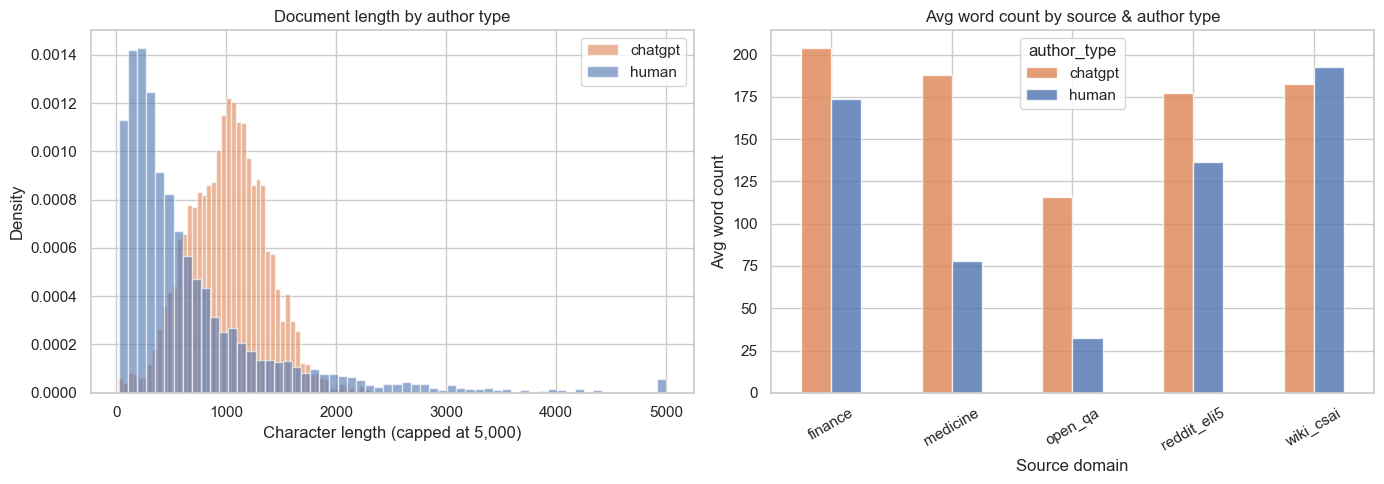

Saved images/eda_overview.png


In [7]:
fig, axes = plt.subplots(1, 2,figsize=(14, 5))

colors = {'human':'#4C72B0', 'chatgpt':'#DD8452'}
for author, grp in docs_sampled.groupby('author_type'):
    axes[0].hist(grp['char_length'].clip(upper=5000), bins=60,
                 alpha=0.6, label=author, density=True, color=colors[author])
axes[0].set_title('Document length by author type')
axes[0].set_xlabel('Character length (capped at 5,000)')
axes[0].set_ylabel('Density')
axes[0].legend()

avg = docs_sampled.groupby(['source','author_type'])['word_count'].mean().unstack()
avg.plot(kind='bar', ax=axes[1], color=[colors['chatgpt'], colors['human']], alpha=0.8)
axes[1].set_title('Avg word count by source & author type')
axes[1].set_xlabel('Source domain')
axes[1].set_ylabel('Avg word count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../images/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved images/eda_overview.png')

## 7. Save docs_sampled

In [8]:
docs_sampled.to_csv('../data/docs_sampled.csv',index=False)
print(f'Saved data/docs_sampled.csv — {len(docs_sampled):,} rows')

Saved data/docs_sampled.csv — 10,258 rows
